<a href="https://colab.research.google.com/github/Saarim02/CPU-Scheduling-Algorithms/blob/main/ID3_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [ ]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Datasets/tennisdata.csv")


In [ ]:
# Encode categorical columns
label_encoders = {}
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [ ]:
# Split into features and target
X = df.drop("PlayTennis", axis=1)
y = df["PlayTennis"]

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Train decision tree with ID3 (entropy)
model = DecisionTreeClassifier(criterion="entropy", random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
# Predict
y_pred = model.predict(X_test)

In [ ]:
# Decode predictions and true values to original string labels
y_test_labels = label_encoders["PlayTennis"].inverse_transform(y_test)
y_pred_labels = label_encoders["PlayTennis"].inverse_transform(y_pred)


In [ ]:
# Print evaluation results
print("Accuracy:", accuracy)
print("\nClassification Report:\n", report)


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



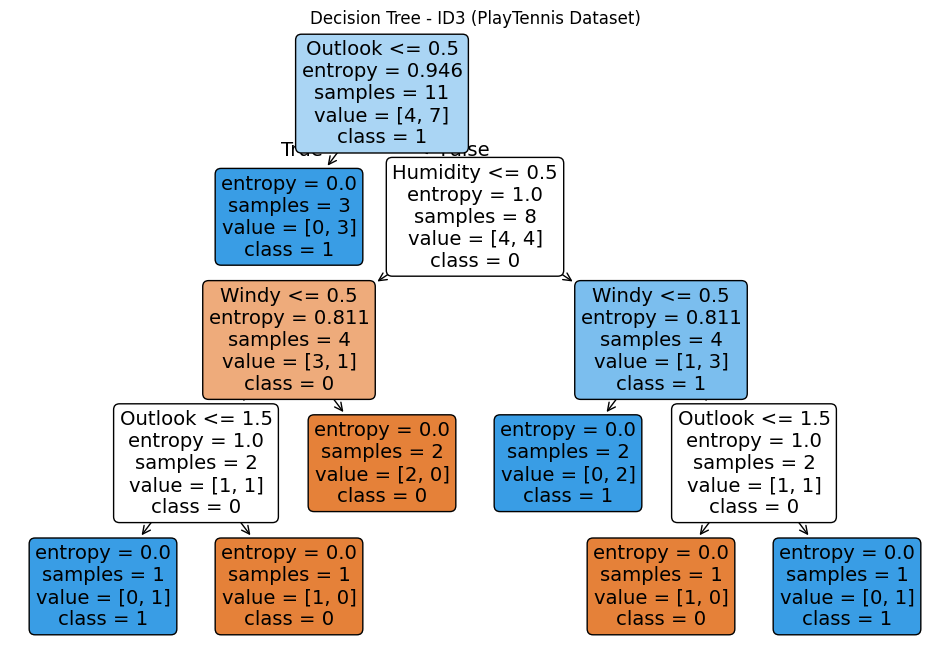

In [ ]:
# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=[str(name) for name in X.columns],  # Ensure strings
    class_names=[str(cls) for cls in label_encoders["PlayTennis"].classes_],  # Ensure strings
    filled=True,
    rounded=True
)
plt.title("Decision Tree - ID3 (PlayTennis Dataset)")
plt.show()